# Bank Loan Report — Python Analysis

End-to-end exploratory analysis and KPI calculation for the **Bank Loan Report**
project. This notebook mirrors the SQL layer in `sql/` and produces the same numbers
that the Power BI, Excel and Tableau dashboards should show.

**Contents**
1. Setup and data load
2. Metadata and descriptive statistics
3. Data quality
4. Dashboard 1 — Summary KPIs
5. Good Loan vs Bad Loan
6. Loan Status grid
7. Dashboard 2 — Overview charts
8. Dashboard 3 — Details

## 1. Setup and data load

In [1]:
import sys
from pathlib import Path

# make the src/ package importable when running the notebook directly
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from bank_loan_report import charts, data_loader, kpis

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
%matplotlib inline

In [2]:
# Loads data/raw/financial_loan.csv when present, otherwise the bundled sample.
# clean_loans() parses the DD-MM-YYYY dates, trims `term`, and adds the helper columns.
df = data_loader.load_loans()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

38,576 rows x 29 columns


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,issue_month,issue_year,issue_month_name,issue_month_short,loan_quality
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,Charged Off,2021-05-13,1314167,car,C4,60 months,Source Verified,"30,000.00",0.01,59.83,0.15,2500,4,1009,2,2021,February,Feb,Bad Loan
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1288686,car,E1,36 months,Source Verified,"48,000.00",0.05,109.43,0.19,3000,4,3939,1,2021,January,Jan,Good Loan
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,Charged Off,2021-02-09,1304116,car,C5,36 months,Not Verified,"50,000.00",0.21,421.65,0.16,12000,11,3522,1,2021,January,Jan,Bad Loan
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,Fully Paid,2021-04-12,1272024,car,B2,60 months,Source Verified,"42,000.00",0.05,97.06,0.11,4500,9,4911,2,2021,February,Feb,Good Loan
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1302971,car,A1,36 months,Verified,"83,000.00",0.02,106.53,0.06,3500,28,3835,1,2021,January,Jan,Good Loan


## 2. Metadata and descriptive statistics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  string        
 2   application_type       38576 non-null  string        
 3   emp_length             38576 non-null  category      
 4   emp_title              37138 non-null  string        
 5   grade                  38576 non-null  string        
 6   home_ownership         38576 non-null  string        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  string        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,"38,576.00","681,037.06","54,734.00","513,517.00","662,728.00","836,506.00","1,077,501.00","211,324.58"
issue_date,38576,2021-07-16 02:31:35.562007040,2021-01-01 00:00:00,2021-04-11 00:00:00,2021-07-11 00:00:00,2021-10-11 00:00:00,2021-12-12 00:00:00,NaN
last_credit_pull_date,38576,2021-06-08 13:36:34.193280512,2021-01-08 00:00:00,2021-04-15 00:00:00,2021-05-16 00:00:00,2021-08-13 00:00:00,2022-01-20 00:00:00,NaN
last_payment_date,38576,2021-06-26 09:52:08.909166080,2021-01-08 00:00:00,2021-03-16 00:00:00,2021-06-14 00:00:00,2021-09-15 00:00:00,2021-12-15 00:00:00,NaN
next_payment_date,38576,2021-07-26 20:42:20.605557760,2021-02-08 00:00:00,2021-04-16 00:00:00,2021-07-14 00:00:00,2021-10-15 00:00:00,2022-01-15 00:00:00,NaN
member_id,"38,576.00","847,651.51","70,699.00","662,978.75","847,356.50","1,045,652.50","1,314,167.00","266,810.46"
annual_income,"38,576.00","69,644.54","4,000.00","41,500.00","60,000.00","83,200.50","6,000,000.00","64,293.68"
dti,"38,576.00",0.13,0.00,0.08,0.13,0.19,0.30,0.07
installment,"38,576.00",326.86,15.69,168.45,283.05,434.44,"1,305.19",209.09
int_rate,"38,576.00",0.12,0.05,0.09,0.12,0.15,0.25,0.04


In [5]:
for col in ["loan_status", "term", "home_ownership", "grade", "verification_status"]:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

loan_status: ['Charged Off', 'Current', 'Fully Paid']
term: ['36 months', '60 months']
home_ownership: ['MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']
grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
verification_status: ['Not Verified', 'Source Verified', 'Verified']


## 3. Data quality

Only `emp_title` has missing values, and it feeds no KPI.

In [6]:
data_loader.data_quality_report(df)

,dtype,nulls,null_pct,distinct
emp_title,string,1438,3.73,28522
id,int64,0,0.00,38576
address_state,string,0,0.00,50
application_type,string,0,0.00,1
emp_length,category,0,0.00,11
grade,string,0,0.00,7
home_ownership,string,0,0.00,5
issue_date,datetime64[ns],0,0.00,65
last_credit_pull_date,datetime64[ns],0,0.00,107
last_payment_date,datetime64[ns],0,0.00,102


In [7]:
print("issue_date range:", df["issue_date"].min().date(), "->", df["issue_date"].max().date())
print("duplicate ids:", int(df["id"].duplicated().sum()))

issue_date range: 2021-01-01 -> 2021-12-12
duplicate ids: 0


## 4. Dashboard 1 — Summary KPIs

`MTD` is the latest month in the data (December 2021); `PMTD` is the month before it.
`int_rate` and `dti` are decimal fractions in the source, so they are multiplied by 100.

In [8]:
year, month = kpis.latest_period(df)
print(f"MTD period: {month:02d}/{year}   PMTD period: %02d/%d" % kpis.previous_period(year, month)[::-1])
kpis.summary_kpis(df)

MTD period: 12/2021   PMTD period: 11/2021


,name,total,mtd,pmtd,mom_pct
0,Total Loan Applications,"38,576.00","4,314.00","4,035.00",6.91
1,Total Funded Amount,"435,757,075.00","53,981,425.00","47,754,825.00",13.04
2,Total Amount Received,"473,070,933.00","58,074,380.00","50,132,030.00",15.84
3,Average Interest Rate,12.05,12.36,11.94,3.47
4,Average DTI,13.33,13.67,13.30,2.73


### Individual KPIs

Each of these matches one query in `sql/02_summary_kpis.sql`.

In [9]:
print(f"Total Loan Applications : {kpis.total_loan_applications(df):,}")
print(f"Total Funded Amount     : ${kpis.total_funded_amount(df):,.0f}")
print(f"Total Amount Received   : ${kpis.total_amount_received(df):,.0f}")
print(f"Average Interest Rate   : {kpis.average_interest_rate(df):.2f}%")
print(f"Average DTI             : {kpis.average_dti(df):.2f}%")

Total Loan Applications : 38,576
Total Funded Amount     : $435,757,075
Total Amount Received   : $473,070,933
Average Interest Rate   : 12.05%
Average DTI             : 13.33%


## 5. Good Loan vs Bad Loan

* Good Loan — `loan_status` is `Fully Paid` or `Current`
* Bad Loan — `loan_status` is `Charged Off`

In [10]:
kpis.good_bad_loan_kpis(df)

,category,loan_status_included,application_pct,applications,funded_amount,amount_received
0,Good Loan,"Fully Paid, Current",86.18,33243,"370,224,850.00","435,786,170.00"
1,Bad Loan,Charged Off,13.82,5333,"65,532,225.00","37,284,763.00"


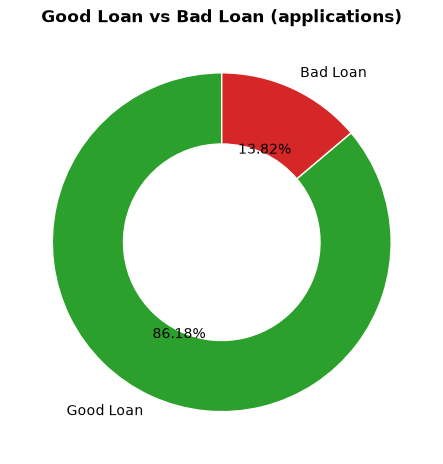

In [11]:
quality = kpis.good_bad_loan_kpis(df)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(quality["applications"], labels=quality["category"], autopct="%1.2f%%",
       startangle=90, colors=["#2ca02c", "#d62728"],
       wedgeprops={"width": 0.42, "edgecolor": "white"})
ax.set_title("Good Loan vs Bad Loan (applications)", fontweight="bold")
plt.show()

## 6. Loan Status grid

In [12]:
kpis.loan_status_grid(df)

,loan_status,total_loan_applications,total_funded_amount,total_amount_received,avg_interest_rate,avg_dti,mtd_funded_amount,mtd_amount_received
0,Charged Off,5333,65532225,37284763,13.88,14.00,8732775,5324211
1,Current,1098,18866500,24199914,15.10,14.72,3946625,4934318
2,Fully Paid,32145,351358350,411586256,11.64,13.17,41302025,47815851


## 7. Dashboard 2 — Overview

Six aggregations, one per required visual.

In [13]:
kpis.by_month(df)

,issue_month,issue_month_name,issue_month_short,total_loan_applications,total_funded_amount,total_amount_received
0,1,January,Jan,2332,25031650,27578836
1,2,February,Feb,2279,24647825,27717745
2,3,March,Mar,2627,28875700,32264400
3,4,April,Apr,2755,29800800,32495533
4,5,May,May,2911,31738350,33750523
5,6,June,Jun,3184,34161475,36164533
6,7,July,Jul,3366,35813900,38827220
7,8,August,Aug,3441,38149600,42682218
8,9,September,Sep,3536,40907725,43983948
9,10,October,Oct,3796,44893800,49399567


In [14]:
kpis.by_state(df).nlargest(10, 'total_funded_amount')

,address_state,total_loan_applications,total_funded_amount,total_amount_received
4,CA,6894,78484125,83901234
33,NY,3701,42077050,46108181
42,TX,2664,31236650,34392715
9,FL,2773,30046125,31601905
30,NJ,1822,21657475,23425159
14,IL,1486,17124225,18875941
44,VA,1375,15982650,17711443
37,PA,1482,15826525,17462908
10,GA,1355,15480325,16728040
19,MA,1310,15051000,16676279


In [15]:
kpis.by_term(df)

,term,total_loan_applications,total_funded_amount,total_amount_received
0,36 months,28237,273041225,294709458
1,60 months,10339,162715850,178361475


In [16]:
kpis.by_emp_length(df)

,emp_length,total_loan_applications,total_funded_amount,total_amount_received
0,< 1 year,4575,44210625,47545011
1,1 year,3229,32883125,35498348
2,2 years,4382,44967975,49206961
3,3 years,4088,43937850,47551832
4,4 years,3428,37600375,40964850
5,5 years,3273,36973625,40397571
6,6 years,2228,25612650,27908658
7,7 years,1772,20811725,22584136
8,8 years,1476,17558950,19025777
9,9 years,1255,15084225,16516173


In [17]:
kpis.by_purpose(df)

,purpose,total_loan_applications,total_funded_amount,total_amount_received
0,Debt consolidation,18214,232459675,253801871
1,credit card,4998,58885175,65214084
2,other,3824,31155750,33289676
3,home improvement,2876,33350775,36380930
4,major purchase,2110,17251600,18676927
5,small business,1776,24123100,23814817
6,car,1497,10223575,11324914
7,wedding,928,9225800,10266856
8,medical,667,5533225,5851372
9,moving,559,3748125,3999899


In [18]:
kpis.by_home_ownership(df)

,home_ownership,total_loan_applications,total_funded_amount,total_amount_received
0,RENT,18439,185768475,201823056
1,MORTGAGE,17198,219329150,238474438
2,OWN,2838,29597675,31729129
3,OTHER,98,1044975,1025257
4,NONE,3,16800,19053


### Charts

`charts.build_all()` renders all six to `reports/figures/`. Here they are inline.

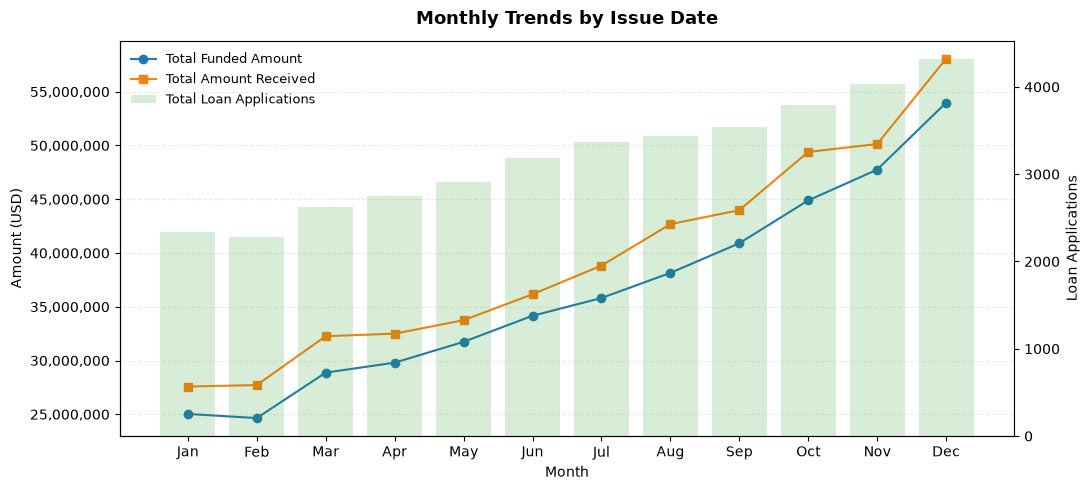

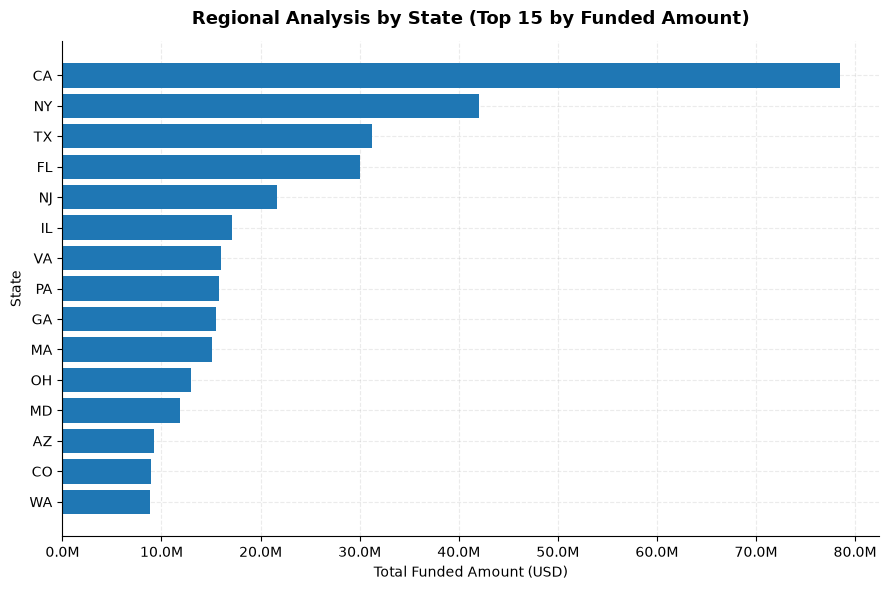

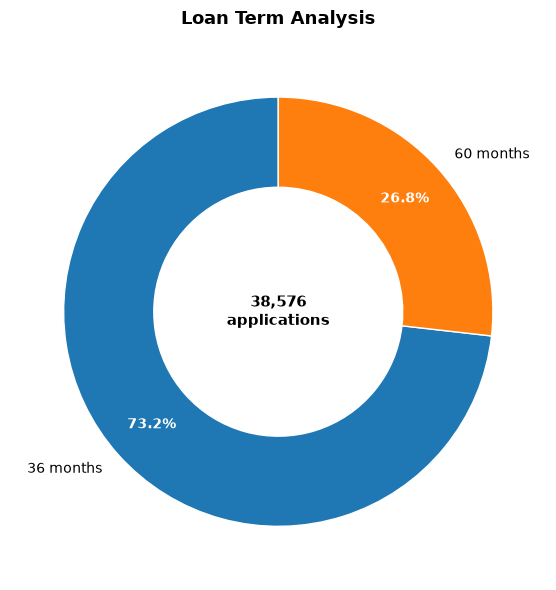

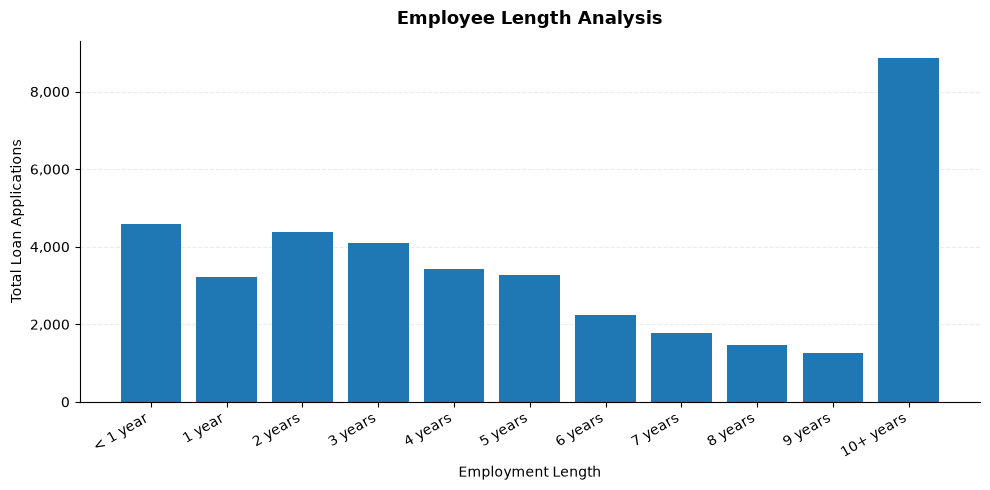

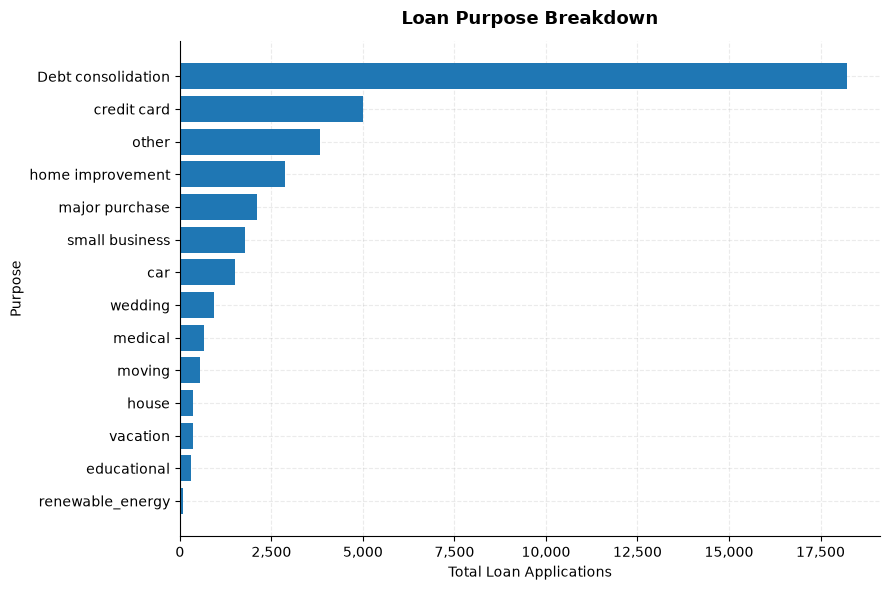

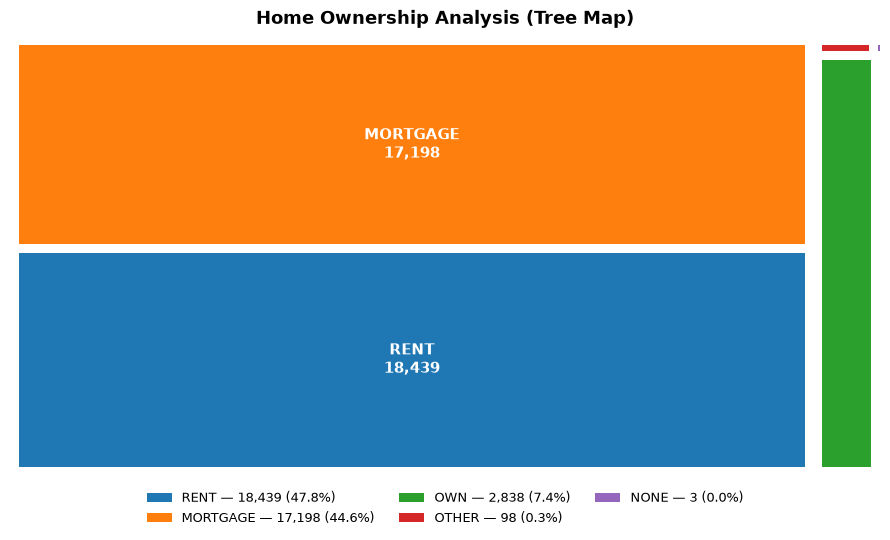

In [19]:
for builder in charts.CHART_BUILDERS:
    builder(df, None)   # outdir=None keeps the figure open for inline display
    plt.show()

In [20]:
# also save them to disk
written = charts.build_all(df)
for path in written:
    print(path)

/home/user/workspace/bank-loan-report-analytics/reports/figures/01_monthly_trend.png
/home/user/workspace/bank-loan-report-analytics/reports/figures/02_state_analysis.png
/home/user/workspace/bank-loan-report-analytics/reports/figures/03_term_donut.png
/home/user/workspace/bank-loan-report-analytics/reports/figures/04_emp_length.png
/home/user/workspace/bank-loan-report-analytics/reports/figures/05_purpose.png
/home/user/workspace/bank-loan-report-analytics/reports/figures/06_home_ownership.png


## 8. Dashboard 3 — Details

In [21]:
kpis.details_table(df, limit=20)

,id,purpose,home_ownership,grade,sub_grade,issue_date,loan_status,term,emp_length,address_state,verification_status,annual_income,dti,int_rate,installment,loan_amount,total_payment
1,1072053,car,RENT,E,E1,2021-01-01,Fully Paid,36 months,9 years,CA,Source Verified,"48,000.00",0.05,0.19,109.43,3000,3939
4,1068350,car,MORTGAGE,A,A1,2021-01-01,Fully Paid,36 months,10+ years,IL,Verified,"83,000.00",0.02,0.06,106.53,3500,3835
2,1069243,car,RENT,C,C5,2021-01-05,Charged Off,36 months,4 years,CA,Not Verified,"50,000.00",0.21,0.16,421.65,12000,3522
7695,235094,Debt consolidation,MORTGAGE,B,B1,2021-01-08,Fully Paid,36 months,10+ years,MD,Not Verified,"55,000.00",0.12,0.09,478.40,15000,17317
7026,209349,Debt consolidation,MORTGAGE,A,A4,2021-01-08,Charged Off,36 months,10+ years,MA,Not Verified,"61,200.00",0.17,0.08,225.86,7200,7309
3611,200912,credit card,MORTGAGE,D,D4,2021-01-08,Fully Paid,36 months,9 years,NY,Not Verified,"50,000.00",0.17,0.13,318.09,9400,11495
24746,231935,educational,RENT,A,A4,2021-01-08,Fully Paid,36 months,1 year,NM,Not Verified,"20,000.00",0.09,0.08,376.43,12000,13462
24747,200886,educational,RENT,A,A5,2021-01-08,Fully Paid,36 months,1 year,WI,Not Verified,"12,000.00",0.00,0.08,293.85,9325,10579
28364,215865,major purchase,RENT,D,D2,2021-01-08,Fully Paid,36 months,3 years,NY,Not Verified,"60,000.00",0.20,0.13,563.40,16800,20282
28361,193586,major purchase,RENT,C,C2,2021-01-08,Fully Paid,36 months,1 year,WA,Not Verified,"25,920.00",0.06,0.11,292.91,9000,10545


---

## Reference numbers

Compare your output with `docs/VERIFICATION.md`. Headline values on the full dataset:

| KPI | Total | MTD | MoM |
|---|---|---|---|
| Applications | 38,576 | 4,314 | +6.91% |
| Funded | \$435,757,075 | \$53,981,425 | +13.04% |
| Received | \$473,070,933 | \$58,074,380 | +15.84% |
| Avg interest rate | 12.05% | 12.36% | +3.47% |
| Avg DTI | 13.33% | 13.67% | +2.73% |

Good loans 86.18% / bad loans 13.82%.